# Ocean Lake sample PAMA-seq (paired-end) QIIME 2 Analysis

#### by Jingjing Cheng and Xiangpeng Li

## Goal
QIIME 2 analysis: PAMA-seq paired-end reads.

## Raw data saved in folder: 
  `/data10/xli/raw_data/miseq_202512_jingjing/OL_PAMA_rename/`
  
## Analysis Folder 
`/data10/xli/project/pama-seq/OL_PAMA_analysis`

### Output dir
`/data10/xli/project/pama-seq/OL_PAMA_analysis/output/`

# Generate manifest.tsv (paired-end)

QIIME 2 paired-end import requires a manifest with:
- sample-id
- forward-absolute-filepath
- reverse-absolute-filepath

We generate the manifest and save the file in `/data10/xli/project/pama-seq/OL_PAMA_analysis/`.

In [159]:
# Generate manifest.tsv (paired-end)
import os
import re

# Input and output paths
input_dir = "/data10/xli/raw_data/miseq_202512_jingjing/OL_PAMA_rename"
output_manifest = "/data10/xli/project/pama-seq/OL_PAMA_analysis/manifest.tsv"

# Regex to extract sample ID
pattern = re.compile(r"(.+)_S\d+_L001_R1_001.fastq.gz")

# Collect R1 files
r1_files = [f for f in os.listdir(input_dir) if f.endswith("_R1_001.fastq.gz")]

with open(output_manifest, "w") as out:
    # Write header
    out.write("sample-id\tforward-absolute-filepath\treverse-absolute-filepath\n")
    
    for r1 in sorted(r1_files):
        match = pattern.match(r1)
        if not match:
            continue
        
        sample_id = match.group(1)
        
        r1_path = os.path.abspath(os.path.join(input_dir, r1))
        r2 = r1.replace("_R1_", "_R2_")
        r2_path = os.path.abspath(os.path.join(input_dir, r2))
        
        if not os.path.exists(r2_path):
            print(f"Warning: Missing R2 file for {sample_id}")
            continue
        
        out.write(f"{sample_id}\t{r1_path}\t{r2_path}\n")

print(f"Manifest saved to: {output_manifest}")

Manifest saved to: /data10/xli/project/pama-seq/OL_PAMA_analysis/manifest.tsv


In [160]:
import os

out_dir = "/data10/xli/project/pama-seq/OL_PAMA_analysis/output/"
os.makedirs(out_dir, exist_ok=True)

# QIIME 2 import 

Import the paired-end reads described in manifest.tsv into a QIIME 2 artifact.

run the following in command line. 

## Demultiplexed read quality assessment (demux summarize)

After importing the paired-end PAMA-seq reads into QIIME 2, we summarize the
demultiplexed data to assess sequencing quality before denoising.

## DADA2 denoising and paired-end merging

After assessing read quality with `demux summarize`, we perform denoising and
paired-end merging using **DADA2**.

### Purpose
This step aims to:
- Correct sequencing errors using a learned error model
- Infer exact amplicon sequence variants (ASVs)
- Merge forward and reverse reads
- Remove chimeric sequences
- Generate a feature table and representative sequences

### Parameter choice
Truncation lengths were selected based on the quality profiles observed in
`demux-paired.qzv`:

- Forward reads (R1): truncated at **280 bp**
- Reverse reads (R2): truncated at **220 bp**

No primer or barcode trimming is applied (`trim-left = 0`) because these
sequences were already removed upstream.

### Execution strategy
DADA2 is computationally intensive.  
To avoid interruption due to network or SSH disconnection, the command is
executed as a **background batch job**.

save the following as "/data10/xli/project/pama-seq/OL_PAMA_analysis/qiime2_pama.sh"
and run the following command:
bash qiime2_pama.sh

In [161]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import os

In [162]:
! ls /data10/xli/project/pama-seq/OL_PAMA_analysis

demux-paired.qza	exported-taxonomy  rep-seqs.qza  untitled.txt
demux-paired.qzv	manifest.tsv	   table.qza
denoising-stats.qza	output		   taxonomy.qza
exported-feature-table	qiime2_pama.sh	   taxonomy.qzv


In [163]:
# Load feature table and taxonomy data from TSV files into pandas DataFrames

import os
import pandas as pd

base_dir = "/data10/xli/project/pama-seq/OL_PAMA_analysis"

ft = pd.read_csv(
    os.path.join(base_dir, "exported-feature-table/feature_table.tsv"),
    sep="\t",
    skiprows=1,
    index_col=0
)

taxonomy = pd.read_csv(
    os.path.join(base_dir, "exported-taxonomy/taxonomy.tsv"),
    sep="\t"
)

In [164]:
ft.head()

,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
#OTU ID,,,,,,,,
fbe95386d8bf61072772099799630738,82327.0,97900.0,124560.0,120971.0,73.0,139.0,156.0,240.0
ac6be611cba1424444b9aa2975c2b7b4,79913.0,95407.0,128280.0,118094.0,80.0,141.0,198.0,162.0
1e69dc1be3d7ebce79c4403528582036,0.0,0.0,0.0,0.0,34871.0,5988.0,2108.0,71899.0
114ebbae22dde659336c1de48981be71,45570.0,36065.0,13827.0,17016.0,0.0,0.0,0.0,0.0
ed5e252a392bff6e27d008177bd0225c,0.0,0.0,0.0,0.0,34768.0,5852.0,2093.0,67998.0


In [165]:
taxonomy.head()

,Feature ID,Taxon,Confidence
0,fbe95386d8bf61072772099799630738,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Mediophyceae;f__Mediophyceae,0.999910
1,ac6be611cba1424444b9aa2975c2b7b4,Unassigned,0.426894
2,1e69dc1be3d7ebce79c4403528582036,d__Eukaryota;p__Arthropoda;c__Maxillopoda;o__Calanoida;f__Calanoida;g__Calanoida;s__,0.992768
3,114ebbae22dde659336c1de48981be71,d__Eukaryota;p__Arthropoda;c__Maxillopoda;o__Calanoida;f__Calanoida;g__Calanoida;s__,0.998515
4,ed5e252a392bff6e27d008177bd0225c,d__Bacteria;p__Proteobacteria;c__Alphaproteobacteria;o__Rickettsiales;f__Mitochondria;g__Mitochondria;s__,0.747280


<Axes: ylabel='Frequency'>

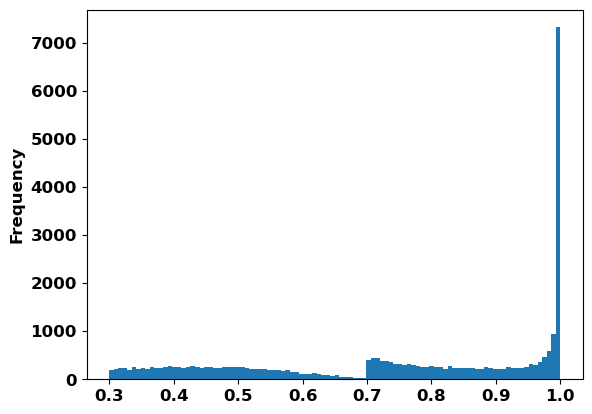

In [166]:
taxonomy.Confidence.plot.hist(bins=100)

In [167]:
# Set "OTU ID" as index, rename it to "Feature ID", and display the updated table

ft.index.name = "Feature ID"
ft.head()

,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
Feature ID,,,,,,,,
fbe95386d8bf61072772099799630738,82327.0,97900.0,124560.0,120971.0,73.0,139.0,156.0,240.0
ac6be611cba1424444b9aa2975c2b7b4,79913.0,95407.0,128280.0,118094.0,80.0,141.0,198.0,162.0
1e69dc1be3d7ebce79c4403528582036,0.0,0.0,0.0,0.0,34871.0,5988.0,2108.0,71899.0
114ebbae22dde659336c1de48981be71,45570.0,36065.0,13827.0,17016.0,0.0,0.0,0.0,0.0
ed5e252a392bff6e27d008177bd0225c,0.0,0.0,0.0,0.0,34768.0,5852.0,2093.0,67998.0


In [168]:
taxonomy.columns

Index(['Feature ID', 'Taxon', 'Confidence'], dtype='object')

In [169]:
# Filter taxonomy by confidence >= 0.90, merge taxonomy with ASV counts, 
# remove Chloroplast/Mitochondria entries, and discard features with zero counts across all samples

import numpy as np

# 0) Ensure expected columns exist in taxonomy
tax = taxonomy[["Feature ID", "Taxon", "Confidence"]].copy()
tax = tax[tax["Confidence"] >= 0.90]

# 1) Use Feature ID as index in taxonomy
tax = tax.set_index("Feature ID")

# 2) Ensure ft index is Feature ID (you already did this)
counts = ft.copy()
counts.index.name = "Feature ID"

# 3) Join taxonomy onto counts (ASV-level master table)
df = counts.join(tax, how="inner")

# 4) Filter out Chloroplast and Mitochondria
mask = ~df["Taxon"].str.contains("Chloroplast|Mitochondria", case=False, na=False)
df = df[mask]

# 5) Remove all-zero features (only based on sample count columns)
sample_cols = counts.columns
df = df.loc[(df[sample_cols] != 0).any(axis=1)].copy()

df.head()

,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b,Taxon,Confidence
Feature ID,,,,,,,,,,
fbe95386d8bf61072772099799630738,82327.0,97900.0,124560.0,120971.0,73.0,139.0,156.0,240.0,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Mediophyceae;f__Mediophyceae,0.999910
1e69dc1be3d7ebce79c4403528582036,0.0,0.0,0.0,0.0,34871.0,5988.0,2108.0,71899.0,d__Eukaryota;p__Arthropoda;c__Maxillopoda;o__Calanoida;f__Calanoida;g__Calanoida;s__,0.992768
114ebbae22dde659336c1de48981be71,45570.0,36065.0,13827.0,17016.0,0.0,0.0,0.0,0.0,d__Eukaryota;p__Arthropoda;c__Maxillopoda;o__Calanoida;f__Calanoida;g__Calanoida;s__,0.998515
814f23eaf5c483399e5a9241f8627296,2946.0,3479.0,0.0,0.0,11763.0,18327.0,10427.0,34406.0,d__Eukaryota;p__Arthropoda;c__Maxillopoda,0.999809
7aca852fc35f7df9dfbbce61860f3594,0.0,5.0,0.0,0.0,5359.0,36658.0,12443.0,8691.0,d__Eukaryota;p__Xenacoelomorpha;c__Acoela;o__Acoela;f__Acoela;g__Acoela;s__,0.998158


In [170]:
print(df.shape)
print(df["Confidence"].min())

(10920, 10)
0.9000243325837191


In [171]:
df.to_csv(out_dir + "ol_df_filtered.csv")

In [ ]:
out_dir

In [172]:
# Parse taxonomy strings into standardized taxonomic ranks (Kingdom to Species) and clean labels

import numpy as np
import pandas as pd

# df must contain a column "Taxon"
tax_str = df["Taxon"].fillna("Unassigned").astype(str)

# 1) Split by ";" into ranks
taxon_levels = tax_str.str.split(";", expand=True)

# 2) Pad/truncate to 8 columns (Domain → Species)
taxon_levels = taxon_levels.reindex(columns=range(8))

# 3) Name columns (PAMA-seq usually starts from Domain)
taxon_levels.columns = [
    "Kingdom", "Phylum", "Class", "Order",
    "Family", "Genus", "Species", "Extra"
]

# 4) Clean prefixes (d__, p__, g__, D_0__, etc.)
def clean_rank(s):
    return (
        s.astype("string")
         .str.strip()
         .str.replace(r"^(?:[a-zA-Z]__)", "", regex=True)
         .str.replace(r"^D_\d+__", "", regex=True)
    )

taxon_levels = taxon_levels.apply(clean_rank)

# 5) Standardize missing labels
taxon_levels = taxon_levels.replace(
    ["", "None", "nan", "Unassigned", "unassigned", "NA", "N/A"],
    np.nan
)

# 6) Drop extra column
taxon_levels = taxon_levels.drop(columns=["Extra"])

taxon_levels.head()

,Kingdom,Phylum,Class,Order,Family,Genus,Species
Feature ID,,,,,,,
fbe95386d8bf61072772099799630738,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,<NA>,<NA>
1e69dc1be3d7ebce79c4403528582036,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,<NA>
114ebbae22dde659336c1de48981be71,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,<NA>
814f23eaf5c483399e5a9241f8627296,Eukaryota,Arthropoda,Maxillopoda,<NA>,<NA>,<NA>,<NA>
7aca852fc35f7df9dfbbce61860f3594,Eukaryota,Xenacoelomorpha,Acoela,Acoela,Acoela,Acoela,<NA>


In [173]:
# Combine count data with cleaned taxonomy, fill missing labels, and remove Chloroplast/Mitochondria features


# 1) Combine ASV count table with parsed taxonomy levels
ol_df_final = pd.concat([df, taxon_levels], axis=1)

# 2) Define taxonomy columns (your version uses Kingdom)
tax_cols = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

# 3) Fill missing taxonomy labels
ol_df_final[tax_cols] = ol_df_final[tax_cols].fillna("Unassigned")

# 3.5) Remove Chloroplast and Mitochondria across all taxonomy levels
tax_levels = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

mask = ~(
    ol_df_final[tax_levels]
    .apply(lambda col: col.str.contains("Chloroplast|Mitochondria", case=False, na=False))
    .any(axis=1)
)

ol_df_final = ol_df_final[mask]
print(f"Rows after removing Chloroplast & Mitochondria: {len(ol_df_final)}")

# 4) Quick check
ol_df_final.head()

Rows after removing Chloroplast & Mitochondria: 10920


,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b,Taxon,Confidence,Kingdom,Phylum,Class,Order,Family,Genus,Species
Feature ID,,,,,,,,,,,,,,,,,
fbe95386d8bf61072772099799630738,82327.0,97900.0,124560.0,120971.0,73.0,139.0,156.0,240.0,d__Eukaryota;p__Diatomea;c__Mediophyceae;o__Mediophyceae;f__Mediophyceae,0.999910,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned
1e69dc1be3d7ebce79c4403528582036,0.0,0.0,0.0,0.0,34871.0,5988.0,2108.0,71899.0,d__Eukaryota;p__Arthropoda;c__Maxillopoda;o__Calanoida;f__Calanoida;g__Calanoida;s__,0.992768,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned
114ebbae22dde659336c1de48981be71,45570.0,36065.0,13827.0,17016.0,0.0,0.0,0.0,0.0,d__Eukaryota;p__Arthropoda;c__Maxillopoda;o__Calanoida;f__Calanoida;g__Calanoida;s__,0.998515,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned
814f23eaf5c483399e5a9241f8627296,2946.0,3479.0,0.0,0.0,11763.0,18327.0,10427.0,34406.0,d__Eukaryota;p__Arthropoda;c__Maxillopoda,0.999809,Eukaryota,Arthropoda,Maxillopoda,Unassigned,Unassigned,Unassigned,Unassigned
7aca852fc35f7df9dfbbce61860f3594,0.0,5.0,0.0,0.0,5359.0,36658.0,12443.0,8691.0,d__Eukaryota;p__Xenacoelomorpha;c__Acoela;o__Acoela;f__Acoela;g__Acoela;s__,0.998158,Eukaryota,Xenacoelomorpha,Acoela,Acoela,Acoela,Acoela,Unassigned


In [174]:
ol_df_final.to_csv(out_dir+ "ol_df_final.csv")

In [175]:
# Reshape data to long format, retain nonzero counts, and remove ambiguous genus labels 
# ("Unassigned" and "uncultured") that lack clear taxonomic resolution for genus-level analysis 


import pandas as pd

# 1) Reset index so Feature ID becomes a column
df0 = ol_df_final.reset_index()   # index name already "Feature ID"

# 2) Identify sample columns (PAMA samples start with "OL-PAMA-")
sample_cols = [c for c in df0.columns if c.startswith("OL-PAMA-")]

# (optional sanity check)
print("Number of samples:", len(sample_cols))
print(sample_cols)

# 3) Convert from wide to long format
tax_cols = ["Kingdom", "Phylum", "Class", "Order", "Family", "Genus", "Species"]

long_df = df0.melt(
    id_vars=["Feature ID"] + tax_cols,
    value_vars=sample_cols,
    var_name="SampleID",
    value_name="Count"
)

long_df = long_df.loc[long_df["Count"] > 0].copy()

long_df_diversity = long_df

bad_genera = ["Unassigned", "uncultured"]
long_df_genus = long_df[~long_df["Genus"].isin(bad_genera)].copy()

long_df_genus.head()

Number of samples: 8
['OL-PAMA-1a', 'OL-PAMA-1b', 'OL-PAMA-2a', 'OL-PAMA-2b', 'OL-PAMA-3a', 'OL-PAMA-3b', 'OL-PAMA-4a', 'OL-PAMA-4b']


,Feature ID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count
2,114ebbae22dde659336c1de48981be71,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned,OL-PAMA-1a,45570.0
9,f338ba87d2657e7168d977dbfc6a33d9,Eukaryota,Ciliophora,Intramacronucleata,Spirotrichea,Choreotrichia,Pelagostrobilidium,Unassigned,OL-PAMA-1a,3844.0
14,50a72f6a7ec72eea5a9406b103b6e88b,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Chaetoceros,Unassigned,OL-PAMA-1a,4603.0
15,d7e8e88e00fae18123b5bf08c8628ab0,Eukaryota,Chlorophyta,Trebouxiophyceae,Incertae_Sedis,Incertae_Sedis,Picochlorum,Unassigned,OL-PAMA-1a,4698.0
17,a513a5274550c81570db81c14be3384c,Eukaryota,Ciliophora,Intramacronucleata,Spirotrichea,Choreotrichia,Pelagostrobilidium,Unassigned,OL-PAMA-1a,1446.0


In [176]:
long_df.head()

,Feature ID,Kingdom,Phylum,Class,Order,Family,Genus,Species,SampleID,Count
0,fbe95386d8bf61072772099799630738,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned,OL-PAMA-1a,82327.0
2,114ebbae22dde659336c1de48981be71,Eukaryota,Arthropoda,Maxillopoda,Calanoida,Calanoida,Calanoida,Unassigned,OL-PAMA-1a,45570.0
3,814f23eaf5c483399e5a9241f8627296,Eukaryota,Arthropoda,Maxillopoda,Unassigned,Unassigned,Unassigned,Unassigned,OL-PAMA-1a,2946.0
5,880658c664f0e8e7fc58217cf49ed129,Eukaryota,Chytridiomycota,Chytridiomycetes,uncultured,uncultured,uncultured,Unassigned,OL-PAMA-1a,9267.0
6,5816f402bcbb7c62e1ac2a9320b229f9,Eukaryota,Diatomea,Mediophyceae,Mediophyceae,Mediophyceae,Unassigned,Unassigned,OL-PAMA-1a,61.0


In [177]:
long_df.to_csv(out_dir+"long_df_pama.csv", index=False)

In [178]:
print(long_df_genus.columns)

print(long_df_genus["Genus"].value_counts().head(10))

print(sorted(long_df_genus["SampleID"].unique()))

Index(['Feature ID', 'Kingdom', 'Phylum', 'Class', 'Order', 'Family', 'Genus',
       'Species', 'SampleID', 'Count'],
      dtype='object')
Genus
OM190                       122
Calanoida                   105
OM27_clade                   87
Woeseia                      83
Cyanobium_PCC-6307           81
BD2-11_terrestrial_group     79
Acoela                       78
Navicula                     77
Blastopirellula              77
Chaetoceros                  75
Name: count, dtype: Int64
['OL-PAMA-1a', 'OL-PAMA-1b', 'OL-PAMA-2a', 'OL-PAMA-2b', 'OL-PAMA-3a', 'OL-PAMA-3b', 'OL-PAMA-4a', 'OL-PAMA-4b']


In [179]:
# Collapse ASV counts to genus-level counts for each sample, convert them to within-sample relative abundance, 
# and build a genus-by-sample abundance matrix

import pandas as pd

# Step 2.1: Sum counts per SampleID × Genus
genus_table = (
    long_df_genus
    .groupby(["SampleID", "Genus"], as_index=False)["Count"]
    .sum()
)

# Step 2.2: Compute relative abundance within each sample
genus_table["RelAbundance"] = (
    genus_table["Count"]
    / genus_table.groupby("SampleID")["Count"].transform("sum")
)

# Step 2.3: Pivot to Sample × Genus matrix
genus_matrix = genus_table.pivot(
    index="Genus",
    columns="SampleID",
    values="RelAbundance"
).fillna(0)

# Quick check
genus_matrix.head()

SampleID,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
Genus,,,,,,,,
028H05-P-BN-P5,0.0,0.000000,0.000000,0.000000,0.000037,0.000032,0.000338,0.000000
0319-6G20,0.0,0.000696,0.000053,0.000000,0.000192,0.000000,0.000021,0.000000
053A03-B-DI-P58,0.0,0.000000,0.000000,0.000000,0.000074,0.000263,0.000253,0.000251
1-20,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000151
11-24,0.0,0.000000,0.000000,0.000491,0.000000,0.000000,0.000000,0.000000


In [180]:
genus_matrix.to_csv(out_dir+"pama_genus_matrix.csv")

In [181]:
genus_matrix.sum()

SampleID
OL-PAMA-1a    1.0
OL-PAMA-1b    1.0
OL-PAMA-2a    1.0
OL-PAMA-2b    1.0
OL-PAMA-3a    1.0
OL-PAMA-3b    1.0
OL-PAMA-4a    1.0
OL-PAMA-4b    1.0
dtype: float64

In [182]:
# Calculate the Spearman correlation between one duplicate sample pair using their genus-level relative abundance vectors

from scipy.stats import spearmanr

# Step 3a.1: Select one duplicate pair
sample_a = "OL-PAMA-1a"
sample_b = "OL-PAMA-1b"

# Step 3a.2: Extract genus-level vectors
vec_a = genus_matrix[sample_a]
vec_b = genus_matrix[sample_b]

# Step 3a.3: Compute Spearman correlation
rho, pval = spearmanr(vec_a, vec_b)

print("Spearman correlation:", round(rho, 3))
print("p-value:", pval)

Spearman correlation: 0.498
p-value: 1.3224565775933846e-61


In [183]:
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

# Select samples
sample_a = "OL-PAMA-1a"
sample_b = "OL-PAMA-1b"

# Extract vectors
x = genus_matrix[sample_a]
y = genus_matrix[sample_b]

# Compute correlation
rho, _ = spearmanr(x, y)

In [184]:
# Automatically identify all PAMA technical replicate pairs (a/b) based on sample naming patterns in the genus-level matrix

# Step 1: detect PAMA replicate pairs (a,b)

samples_pama = sorted([s for s in genus_matrix.columns if s.startswith("OL-PAMA-")])

indices = sorted(set([s.split("-")[-1].split("a")[0].split("b")[0] for s in samples_pama]))

pairs_pama = []
for i in indices:
    a_candidates = [c for c in genus_matrix.columns if c.startswith(f"OL-PAMA-{i}a")]
    b_candidates = [c for c in genus_matrix.columns if c.startswith(f"OL-PAMA-{i}b")]

    if (len(a_candidates) > 0) and (len(b_candidates) > 0):
        pairs_pama.append((a_candidates[0], b_candidates[0]))

print("Detected pairs:", pairs_pama)

Detected pairs: [('OL-PAMA-1a', 'OL-PAMA-1b'), ('OL-PAMA-2a', 'OL-PAMA-2b'), ('OL-PAMA-3a', 'OL-PAMA-3b'), ('OL-PAMA-4a', 'OL-PAMA-4b')]


In [185]:
# Verify that all detected replicate pairs are present in the genus-level matrix and report any missing samples

# Step 1 (PAMA): check pairs exist in genus_matrix

pairs = pairs_pama

missing = []
for sample_a, sample_b in pairs:
    a_ok = sample_a in genus_matrix.columns
    b_ok = sample_b in genus_matrix.columns
    if (not a_ok) or (not b_ok):
        missing.append((sample_a, sample_b, a_ok, b_ok))

print("Total pairs:", len(pairs))
print("Missing:", missing)

Total pairs: 4
Missing: []


In [186]:
# Step 2: focus on ONE sample (PAMA replicate a vs b)

sample_a, sample_b = pairs_pama[0]

x = genus_matrix[sample_a]
y = genus_matrix[sample_b]

mask = (x > 0) | (y > 0)

print("Total genera in full matrix:", len(x))
print("Genera present in this sample:", mask.sum())

Total genera in full matrix: 964
Genera present in this sample: 297


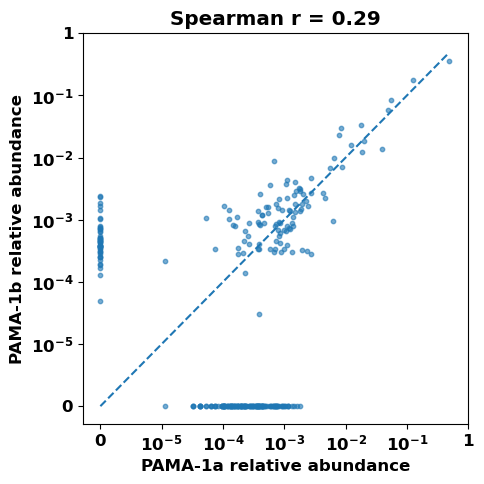

Filtered genera used: 297
Spearman r (filtered): 0.2871830175638918


In [187]:
# Step 3: compute correlation + plot using ONLY genera present in this sample

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr

pseudo = 1e-6

# 1) apply mask (keep only genera present in at least one replicate)
x_sub = x[mask]
y_sub = y[mask]

# 2) Spearman correlation on the filtered vectors
rho, _ = spearmanr(x_sub, y_sub)

# 3) Log10 for plotting (avoid log(0) using pseudo)
x_log = np.log10(x_sub + pseudo)
y_log = np.log10(y_sub + pseudo)

plt.figure(figsize=(5, 5))
plt.scatter(x_log, y_log, s=10, alpha=0.6)

# diagonal reference line
min_val = min(x_log.min(), y_log.min())
max_val = max(x_log.max(), y_log.max())
plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

ticks = [-6, -5, -4, -3, -2, -1, 0]
labels = ["0", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$", r"$10^{-2}$", r"$10^{-1}$", "1"]
plt.xticks(ticks, labels)
plt.yticks(ticks, labels)

label_a = sample_a.replace("OL-", "")
label_b = sample_b.replace("OL-", "")

plt.xlabel(f"{label_a} relative abundance")
plt.ylabel(f"{label_b} relative abundance")

plt.title(f"Spearman r = {rho:.2f}")

plt.tight_layout()
plt.show()

print("Filtered genera used:", len(x_sub))
print("Spearman r (filtered):", rho)

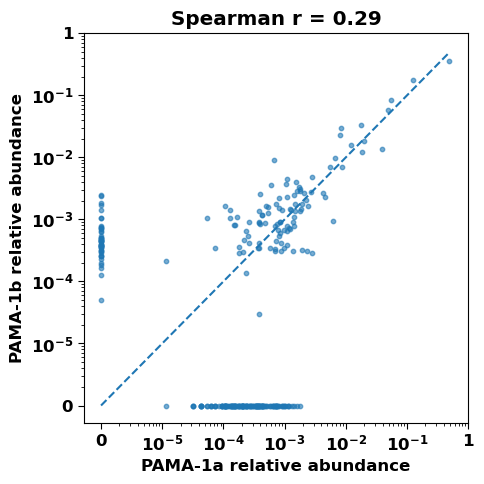

OL-PAMA-1a vs OL-PAMA-1b | genera used: 297 | Spearman r: 0.287


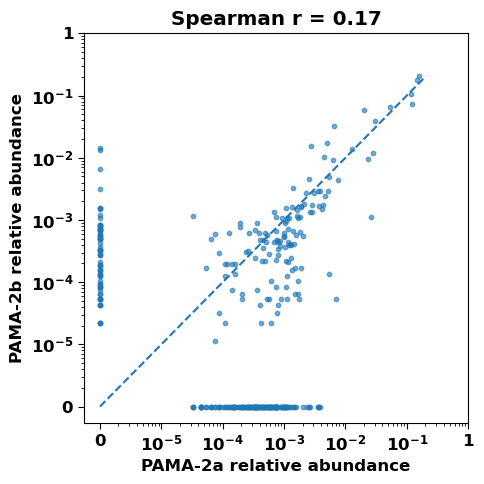

OL-PAMA-2a vs OL-PAMA-2b | genera used: 336 | Spearman r: 0.168


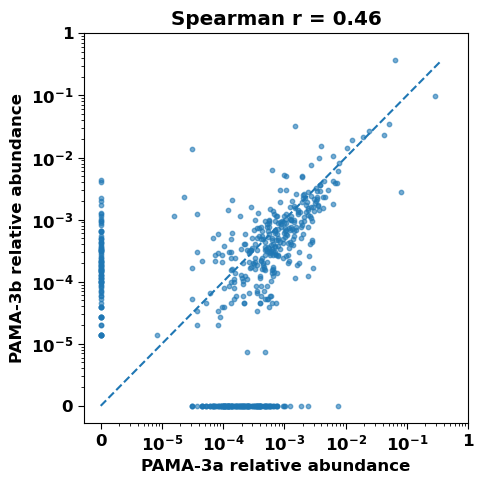

OL-PAMA-3a vs OL-PAMA-3b | genera used: 586 | Spearman r: 0.458


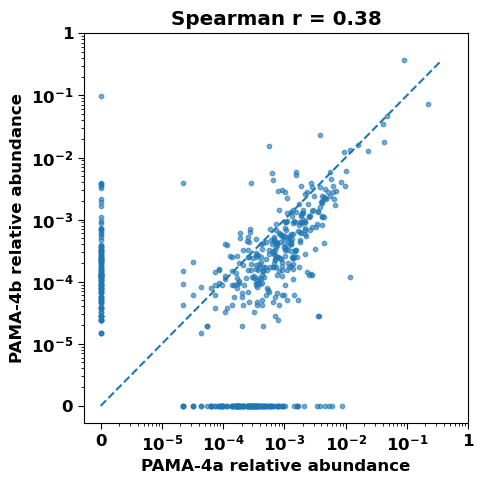

OL-PAMA-4a vs OL-PAMA-4b | genera used: 586 | Spearman r: 0.38


In [188]:
"""
1. Configure global plotting styles (fonts, weights, and Illustrator-compatible settings) 
   and define custom minor ticks for log-scaled axes

2. Iterate over all detected PAMA replicate pairs and extract genus-level relative abundance vectors 
   with nonzero presence filtering

3. Compute Spearman correlation and generate log10-transformed scatter plots to visualize replicate consistency
"""


import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import spearmanr
import matplotlib.ticker as ticker

pseudo = 1e-6

# =========================
# Global style (safe on Linux/HPC)
# =========================
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Helvetica"]
plt.rcParams["pdf.fonttype"] = 42   # editable text in Illustrator
plt.rcParams["ps.fonttype"] = 42

# Make fonts bold-ish (optional)
plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"

# Font sizes (edit here)
FS_TITLE = 16
FS_AXLABEL = 16
FS_TICK = 12
FS_LEGEND = 11
FS_LEGEND_TITLE = 12


# ---- ADD: log-style minor ticks for log10-transformed axes ----
def add_log10_minor_ticks(ax, major_ticks):
    """
    major_ticks: e.g. [-6, -5, -4, -3, -2, -1, 0]
    Adds minor ticks at k + log10(2..9) for each interval [k, k+1].
    Use when your plotted values are already log10-transformed (linear axis).
    """
    subs = np.log10(np.arange(2, 10))  # log10(2..9)
    minor = []
    for k in major_ticks[:-1]:
        minor.extend(list(k + subs))

    ax.xaxis.set_minor_locator(ticker.FixedLocator(minor))
    ax.yaxis.set_minor_locator(ticker.FixedLocator(minor))

    # minor ticks: marks only, no labels
    ax.xaxis.set_minor_formatter(ticker.NullFormatter())
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())

    ax.tick_params(which="major", length=4, width=0.8, direction="out")
    ax.tick_params(which="minor", length=2, width=0.6, direction="out")


for sample_a, sample_b in pairs_pama:

    x = genus_matrix[sample_a]
    y = genus_matrix[sample_b]

    # sample-specific genus space
    mask = (x > 0) | (y > 0)

    x_sub = x[mask]
    y_sub = y[mask]

    rho, _ = spearmanr(x_sub, y_sub)

    x_log = np.log10(x_sub + pseudo)
    y_log = np.log10(y_sub + pseudo)

    plt.figure(figsize=(5, 5))
    plt.scatter(x_log, y_log, s=10, alpha=0.6)

    min_val = min(x_log.min(), y_log.min())
    max_val = max(x_log.max(), y_log.max())
    plt.plot([min_val, max_val], [min_val, max_val], linestyle="--")

    ticks = [-6, -5, -4, -3, -2, -1, 0]
    labels = ["0", r"$10^{-5}$", r"$10^{-4}$", r"$10^{-3}$",
              r"$10^{-2}$", r"$10^{-1}$", "1"]
    plt.xticks(ticks, labels)
    plt.yticks(ticks, labels)

    # ---- ADD THIS: log-style "one-bar-one-bar" minor ticks ----
    ax = plt.gca()
    add_log10_minor_ticks(ax, ticks)

    label_a = sample_a.replace("OL-", "").split("_")[0]
    label_b = sample_b.replace("OL-", "").split("_")[0]

    plt.xlabel(f"{label_a} relative abundance")
    plt.ylabel(f"{label_b} relative abundance")

    plt.title(f"Spearman r = {rho:.2f}")

    plt.tight_layout()
    plt.savefig(out_dir+ f"{sample_a}_vs_{sample_b}_shared_genus.pdf",
                bbox_inches="tight")
    plt.show()

    print(
        sample_a, "vs", sample_b,
        "| genera used:", len(x_sub),
        "| Spearman r:", round(rho, 3)
    )

In [189]:
tmp = genus_matrix.reset_index()
tmp.iloc[:, 0] = '="' + tmp.iloc[:, 0].astype(str) + '"'
tmp.to_csv(out_dir+ "pama_replicate_consistency.csv", index=False)

In [190]:
# Calculate alpha diversity metrics (total counts, observed features, and Shannon index) 
# for each sample based on ASV count data

import numpy as np
import pandas as pd

def shannon_from_counts(x):
    p = x / x.sum()
    return -(p * np.log(p)).sum()

alpha = pd.DataFrame({
    "depth": long_df.groupby("SampleID")["Count"].sum(),
    "observed_features": long_df.groupby("SampleID")["Feature ID"].nunique(),
    "shannon": long_df.groupby("SampleID")["Count"].apply(shannon_from_counts)
})

alpha

,depth,observed_features,shannon
SampleID,,,
OL-PAMA-1a,223342.0,851,3.032200
OL-PAMA-1b,260414.0,660,3.151664
OL-PAMA-2a,265878.0,881,3.082300
OL-PAMA-2b,274977.0,646,2.895805
OL-PAMA-3a,221404.0,2541,5.494644
OL-PAMA-3b,272822.0,1979,4.983548
OL-PAMA-4a,162841.0,2458,5.818821
OL-PAMA-4b,366851.0,2518,4.605866


In [191]:


alpha.to_csv(f"{out_dir}/alpha_metrics.csv")

In [192]:
# Aggregate ASV counts to phylum level and construct a phylum-by-sample count table


phylum_table = (
    long_df
    .groupby(["Phylum", "SampleID"])["Count"]
    .sum()
    .unstack(fill_value=0)
)

In [193]:
# Convert phylum-level counts to relative abundance within each sample

phylum_rel = phylum_table.div(phylum_table.sum(axis=0), axis=1)

In [194]:
# Export phylum-level relative abundance table to CSV and preview the result

phylum_rel.to_csv(f"{out_dir}/phylum_relative_abundance.csv")
phylum_rel.head()

SampleID,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
Phylum,,,,,,,,
Acidobacteriota,0.003730,0.002723,0.003885,0.002786,0.003830,0.001774,0.004980,0.001499
Actinobacteriota,0.009891,0.008909,0.011667,0.006753,0.011170,0.007305,0.014327,0.004637
Altiarchaeota,0.000000,0.000000,0.000000,0.000000,0.000126,0.000000,0.000000,0.000000
Amoebozoa,0.000022,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
Ancyromonadida,0.000000,0.000000,0.000000,0.000000,0.000086,0.000000,0.000000,0.000090


In [195]:
# Exclude ambiguous phylum labels from ranking
# then identify the top 20 phyla based on total relative abundance across samples

ps = phylum_rel.copy()

bad_labels = ["Unassigned", "uncultured", "unknown", "unidentified", "metagenome"]

rank_base = ps.drop(index=bad_labels, errors="ignore")

top20 = (
    rank_base.sum(axis=1)
    .sort_values(ascending=False)
    .head(20)
    .index
    .tolist()
)

top20

['Diatomea',
 'Arthropoda',
 'Proteobacteria',
 'Xenacoelomorpha',
 'Chlorophyta',
 'Ciliophora',
 'Bacteroidota',
 'Chytridiomycota',
 'Cnidaria',
 'Cryptophyceae',
 'Cercozoa',
 'Ochrophyta',
 'Planctomycetota',
 'Protalveolata',
 'Actinobacteriota',
 'Mollusca',
 'Verrucomicrobiota',
 'Labyrinthulomycetes',
 'Desulfobacterota',
 'Cyanobacteria']

In [196]:
# Build Top20 + Other table
phylum_top = ps.loc[top20].copy()

# Everything else -> Other (including Unassigned/uncultured/unknown/etc and all non-top20 phyla)
other = ps.drop(index=top20, errors="ignore").sum(axis=0)
phylum_top.loc["Other"] = other

# Ensure each sample sums to exactly 1
phylum_top = phylum_top.div(phylum_top.sum(axis=0), axis=1)

# Put Other at the bottom; keep top20 order as-is (your list is already abundance-sorted)
phylum_top = phylum_top.loc[top20 + ["Other"]]

print("Per-sample sums (should be 1.0):")
print(phylum_top.sum(axis=0).round(6))

phylum_top.head()

Per-sample sums (should be 1.0):
SampleID
OL-PAMA-1a    1.0
OL-PAMA-1b    1.0
OL-PAMA-2a    1.0
OL-PAMA-2b    1.0
OL-PAMA-3a    1.0
OL-PAMA-3b    1.0
OL-PAMA-4a    1.0
OL-PAMA-4b    1.0
dtype: float64


SampleID,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
Phylum,,,,,,,,
Diatomea,0.458646,0.453704,0.550580,0.546446,0.209233,0.282532,0.217273,0.233029
Arthropoda,0.219994,0.153502,0.052611,0.062202,0.277547,0.153265,0.167261,0.364734
Proteobacteria,0.029238,0.032210,0.039037,0.022536,0.134672,0.072567,0.128395,0.066351
Xenacoelomorpha,0.000000,0.000019,0.041275,0.036887,0.039579,0.212446,0.129844,0.043604
Chlorophyta,0.059707,0.075272,0.046785,0.030708,0.011152,0.015604,0.013197,0.008614


In [197]:
# Adjust pandas display settings and preview the full phylum-level relative abundance table (top taxa + Other)

import pandas as pd

pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.max_colwidth", None)

phylum_top

SampleID,OL-PAMA-1a,OL-PAMA-1b,OL-PAMA-2a,OL-PAMA-2b,OL-PAMA-3a,OL-PAMA-3b,OL-PAMA-4a,OL-PAMA-4b
Phylum,,,,,,,,
Diatomea,0.458646,0.453704,0.550580,0.546446,0.209233,0.282532,0.217273,0.233029
Arthropoda,0.219994,0.153502,0.052611,0.062202,0.277547,0.153265,0.167261,0.364734
Proteobacteria,0.029238,0.032210,0.039037,0.022536,0.134672,0.072567,0.128395,0.066351
Xenacoelomorpha,0.000000,0.000019,0.041275,0.036887,0.039579,0.212446,0.129844,0.043604
Chlorophyta,0.059707,0.075272,0.046785,0.030708,0.011152,0.015604,0.013197,0.008614
Ciliophora,0.044045,0.042559,0.064146,0.074559,0.001942,0.002375,0.002905,0.005005
Bacteroidota,0.008928,0.006789,0.009418,0.004677,0.058432,0.034994,0.064965,0.031607
Chytridiomycota,0.042907,0.053473,0.038416,0.052710,0.000000,0.000000,0.000000,0.000000
Cnidaria,0.000170,0.001010,0.000000,0.000000,0.053450,0.027109,0.021960,0.072893


In [198]:
import numpy as np
import matplotlib.pyplot as plt

samples = phylum_top.columns.tolist()         
sh = alpha.loc[samples, "shannon"]        
sh

SampleID
OL-PAMA-1a    3.032200
OL-PAMA-1b    3.151664
OL-PAMA-2a    3.082300
OL-PAMA-2b    2.895805
OL-PAMA-3a    5.494644
OL-PAMA-3b    4.983548
OL-PAMA-4a    5.818821
OL-PAMA-4b    4.605866
Name: shannon, dtype: float64

In [199]:
short_names = [
    s.replace("OL-PAMA-", "").split("_")[0]
    for s in phylum_top.columns
]

In [200]:
phylum_top_short = phylum_top.copy()
phylum_top_short.columns = short_names

In [201]:
shannon_short = sh.values

In [202]:
print(phylum_top_short.columns)
print(shannon_short)

Index(['1a', '1b', '2a', '2b', '3a', '3b', '4a', '4b'], dtype='object')
[3.0322     3.1516642  3.08230047 2.89580536 5.49464408 4.98354785
 5.81882092 4.60586576]


In [203]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.family": "DejaVu Sans",   
    "mathtext.fontset": "dejavusans",
    "svg.fonttype": "none",         
    "pdf.fonttype": 42,            
})

/tmp/ipykernel_2037124/213532962.py:80: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


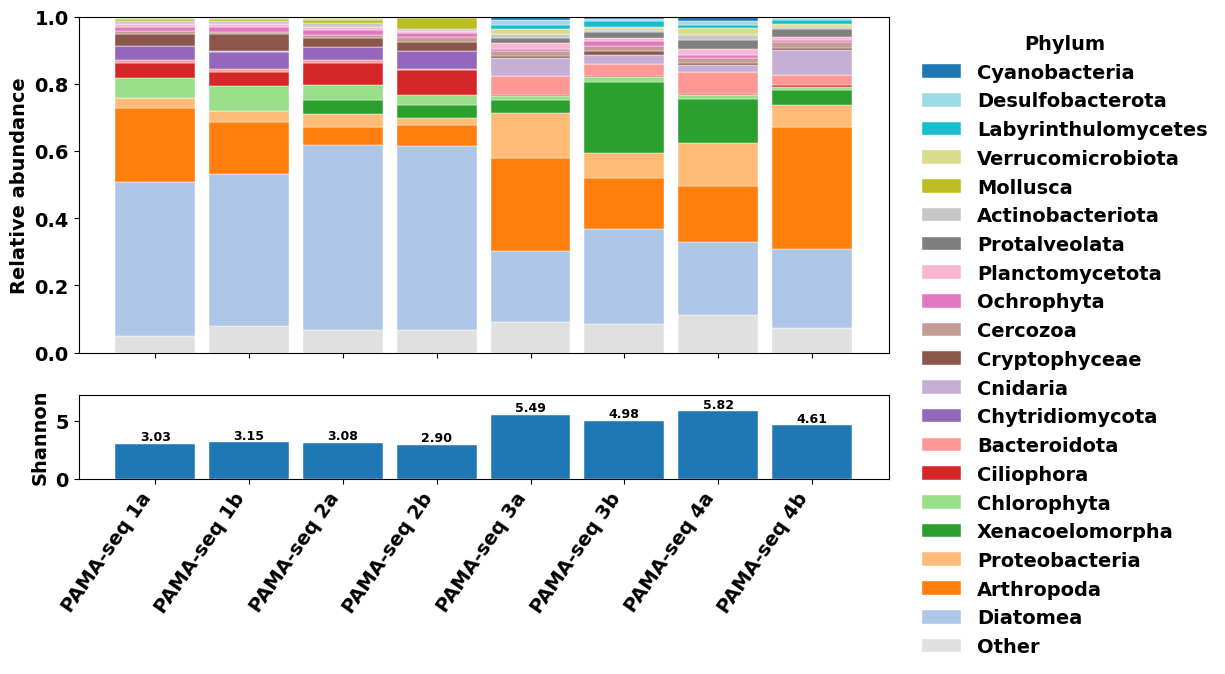

In [204]:
# Configure plotting styles and align sample order, 
# then generate a two-panel figure showing phylum-level stacked relative abundance and Shannon diversity across samples


import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["font.weight"] = "bold"
plt.rcParams["axes.labelweight"] = "bold"
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["font.family"] = "sans-serif"
plt.rcParams["font.sans-serif"] = ["DejaVu Sans", "Liberation Sans", "Helvetica"]
plt.rcParams["font.size"] = 14

samples_original = phylum_top_short.columns.tolist()

# ---- Align order ----
samples = phylum_top_short.columns.tolist()
sh = np.array(shannon_short)   # aligned with samples

# ---- Data for stacked bar ----
plot_df = phylum_top_short.T  # rows=samples, cols=taxa

# Bottom -> top stacking order (Other at bottom)
taxa = plot_df.columns.tolist()
taxa_bottom_to_top = (["Other"] if "Other" in taxa else []) + [t for t in taxa if t != "Other"]
plot_df = plot_df[taxa_bottom_to_top]

# ---- Colors ----
cmap = plt.get_cmap("tab20")
colors = {t: ((0.88, 0.88, 0.88, 1.0) if t == "Other" else cmap(i % 20))
          for i, t in enumerate(taxa_bottom_to_top)}

# ---- Figure: two stacked panels ----
fig = plt.figure(figsize=(12, 6))
gs = fig.add_gridspec(nrows=2, ncols=1, height_ratios=[12, 3], hspace=0.20)

ax1 = fig.add_subplot(gs[0, 0])              # stacked bar
ax2 = fig.add_subplot(gs[1, 0], sharex=ax1)  # shannon bar

x = np.arange(len(samples))

# ===== Top panel: stacked relative abundance =====
bottom = np.zeros(len(samples))
handles, labels = [], []

for t in taxa_bottom_to_top:
    bars = ax1.bar(
        x, plot_df[t].values,
        bottom=bottom, width=0.85,
        color=colors[t], edgecolor="white", linewidth=0.3, label=t
    )
    bottom += plot_df[t].values
    handles.append(bars[0])
    labels.append(t)

ax1.set_ylim(0, 1.0)
ax1.set_ylabel("Relative abundance")
ax1.tick_params(axis="x", labelbottom=False)

# Legend order: match visual TOP -> BOTTOM
ax1.legend(handles[::-1], labels[::-1],
           bbox_to_anchor=(1.02, 1), loc="upper left",
           frameon=False, title="Phylum")

# ===== Bottom panel: Shannon bar chart =====
ax2.bar(x, sh, width=0.85, edgecolor="white", linewidth=0.3)
ax2.set_ylabel("Shannon")
ax2.set_xticks(x)
new_labels = [f"PAMA-seq {s}" for s in samples]
ax2.set_xticklabels(new_labels, rotation=55, ha="right")
ax2.set_ylim(0, np.max(sh) * 1.25)

# Optional: put numbers on top of Shannon bars
for i, v in enumerate(sh):
    ax2.text(i, v + 0.05, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

# Layout (leave room for legend)
plt.subplots_adjust(right=0.80)
plt.tight_layout()
plt.savefig(out_dir+"PAMA-barplot.svg", bbox_inches="tight", pad_inches=0.02)
plt.show()

In [205]:
fig_data = phylum_top_short.T.copy()
fig_data["Shannon"] = alpha["shannon"]

fig_data.to_csv(out_dir+"pama_phylum_shannon_data.csv")

In [206]:
# Define river and ocean sample groups, and construct filtered phylum- and genus-level datasets 
# by removing ambiguous labels (e.g., unassigned/uncultured) for downstream comparison

import numpy as np
import pandas as pd
from scipy.stats import mannwhitneyu

# Sample groups
river_samples  = ["OL-PAMA-1a", "OL-PAMA-1b", "OL-PAMA-2a",
                 "OL-PAMA-2b"]
ocean_samples = ["OL-PAMA-3a", "OL-PAMA-3b",
                 "OL-PAMA-4a", "OL-PAMA-4b"]

bad_labels = ["Unassigned", "uncultured"]

# Filtered dataframes
long_df_phylum = long_df[~long_df["Phylum"].isin(bad_labels)].copy()
long_df_genus2 = long_df[~long_df["Genus"].isin(bad_labels)].copy()

print("long_df original rows:", len(long_df))
print("long_df_phylum rows:", len(long_df_phylum))
print("long_df_genus2 rows:", len(long_df_genus2))

long_df original rows: 12534
long_df_phylum rows: 11925
long_df_genus2 rows: 7195


In [207]:
# Compute total AFTER removing unassigned/uncultured (correct denominator)
total_genus  = long_df_genus2.groupby("SampleID")["Count"].sum()

long_df_genus2["RelAbundance"] = long_df_genus2["Count"] / long_df_genus2["SampleID"].map(total_genus)

# Aggregate by Phylum/Genus per sample
genus_agg  = long_df_genus2.groupby(["Genus",  "SampleID"])["RelAbundance"].sum().reset_index()

print("Genus aggregated shape:",  genus_agg.shape)
print("\nSample check (genus, should be exactly 1.0 per sample):")
print(genus_agg.groupby("SampleID")["RelAbundance"].sum())

Genus aggregated shape: (2677, 3)

Sample check (genus, should be exactly 1.0 per sample):
SampleID
OL-PAMA-1a    1.0
OL-PAMA-1b    1.0
OL-PAMA-2a    1.0
OL-PAMA-2b    1.0
OL-PAMA-3a    1.0
OL-PAMA-3b    1.0
OL-PAMA-4a    1.0
OL-PAMA-4b    1.0
Name: RelAbundance, dtype: float64


In [208]:
print(genus_matrix.shape)
print(genus_matrix.index[:5].tolist())
print(genus_matrix.columns[:5].tolist())

(964, 8)
['028H05-P-BN-P5', '0319-6G20', '053A03-B-DI-P58', '1-20', '11-24']
['OL-PAMA-1a', 'OL-PAMA-1b', 'OL-PAMA-2a', 'OL-PAMA-2b', 'OL-PAMA-3a']


In [209]:
# Transpose: rows = samples, columns = genera
genus_matrix_T = genus_matrix.T

# Clean sample names: remove "_S14" etc
genus_matrix_T.index = genus_matrix_T.index.str.replace(r'_S\d+', '', regex=True)

print(genus_matrix_T.shape)
print(genus_matrix_T.index.tolist())

(8, 964)
['OL-PAMA-1a', 'OL-PAMA-1b', 'OL-PAMA-2a', 'OL-PAMA-2b', 'OL-PAMA-3a', 'OL-PAMA-3b', 'OL-PAMA-4a', 'OL-PAMA-4b']


In [210]:
# Pivot: rows = genus, columns = samples
genus_heat = genus_agg.pivot_table(
    index="Genus",
    columns="SampleID",
    values="RelAbundance",
    fill_value=0
)

print(genus_heat.shape)

(964, 8)


In [211]:
import pandas as pd
pd.set_option("display.max_rows", None)
pd.set_option("display.max_columns", None)
print(genus_heat)

SampleID                                            OL-PAMA-1a  OL-PAMA-1b  \
Genus                                                                        
028H05-P-BN-P5                                        0.000000    0.000000   
0319-6G20                                             0.000000    0.000696   
053A03-B-DI-P58                                       0.000000    0.000000   
1-20                                                  0.000000    0.000000   
11-24                                                 0.000000    0.000000   
211ds20                                               0.000000    0.000000   
37-13                                                 0.000438    0.000000   
4-29-1                                                0.000000    0.000441   
4572-13                                               0.000000    0.000000   
67-14                                                 0.000699    0.000333   
A0839                                                 0.000355  

In [212]:
print(genus_heat.sum(axis=0))

SampleID
OL-PAMA-1a    1.0
OL-PAMA-1b    1.0
OL-PAMA-2a    1.0
OL-PAMA-2b    1.0
OL-PAMA-3a    1.0
OL-PAMA-3b    1.0
OL-PAMA-4a    1.0
OL-PAMA-4b    1.0
dtype: float64


In [213]:
genus_heat.to_csv(out_dir+"genus_pama_normalized.csv")

In [214]:
# Retain genera with RelAbundance > 0.001 in at least one sample
threshold = 0.001
genus_filtered = genus_heat[genus_heat.max(axis=1) > threshold]

print(f"Number of genera remaining after filtering: {genus_filtered.shape[0]}")

Number of genera remaining after filtering: 298


In [215]:
print(genus_filtered.sum(axis=0))

SampleID
OL-PAMA-1a    0.959902
OL-PAMA-1b    0.974259
OL-PAMA-2a    0.951062
OL-PAMA-2b    0.974249
OL-PAMA-3a    0.912619
OL-PAMA-3b    0.946701
OL-PAMA-4a    0.911389
OL-PAMA-4b    0.951855
dtype: float64


In [216]:
# Average technical replicates (a/b) for each PAMA sample to 
# obtain a single genus-level relative abundance profile per sample, and verify normalization

genus_filtered_sub = genus_filtered.copy()

# Average the a and b replicates
genus_merged = pd.DataFrame({
    "PAMA-1": (genus_filtered_sub["OL-PAMA-1a"] + genus_filtered_sub["OL-PAMA-1b"]) / 2,
    "PAMA-2": (genus_filtered_sub["OL-PAMA-2a"] + genus_filtered_sub["OL-PAMA-2b"]) / 2,
    "PAMA-3": (genus_filtered_sub["OL-PAMA-3a"] + genus_filtered_sub["OL-PAMA-3b"]) / 2,
    "PAMA-4": (genus_filtered_sub["OL-PAMA-4a"] + genus_filtered_sub["OL-PAMA-4b"]) / 2,
})

# Verify
print("Shape:", genus_merged.shape)
print("\nColumns:", genus_merged.columns.tolist())
print("\nColumn sums (should be close to 1.0):")
print(genus_merged.sum(axis=0))
print(genus_merged.head())

Shape: (298, 4)

Columns: ['PAMA-1', 'PAMA-2', 'PAMA-3', 'PAMA-4']

Column sums (should be close to 1.0):
PAMA-1    0.967081
PAMA-2    0.962655
PAMA-3    0.929660
PAMA-4    0.931622
dtype: float64
                           PAMA-1    PAMA-2    PAMA-3    PAMA-4
Genus                                                          
67-14                    0.000516  0.000782  0.000205  0.000246
A4b                      0.000047  0.000162  0.000703  0.000259
ADurb.Bin063-1           0.000520  0.000567  0.000000  0.000000
AEGEAN-169_marine_group  0.001412  0.003264  0.001158  0.000767
AKYH767                  0.000516  0.000700  0.000000  0.000000


In [217]:
genus_merged.head()

,PAMA-1,PAMA-2,PAMA-3,PAMA-4
Genus,,,,
67-14,0.000516,0.000782,0.000205,0.000246
A4b,0.000047,0.000162,0.000703,0.000259
ADurb.Bin063-1,0.000520,0.000567,0.000000,0.000000
AEGEAN-169_marine_group,0.001412,0.003264,0.001158,0.000767
AKYH767,0.000516,0.000700,0.000000,0.000000


In [218]:
# Apply row-wise z-score normalization to genus-level relative abundance to center and scale each genus across samples, 
# and verify mean ~0 and standard deviation ~1

from scipy.stats import zscore

genus_z_merged = genus_merged.apply(zscore, axis=1, result_type='expand')

# Verify
print("Shape:", genus_z_merged.shape)
print(genus_z_merged.head())
print("\nRow means (should be close to 0):")
print(genus_z_merged.mean(axis=1).head())
print("\nRow standard deviations (should be close to 1):")
print(genus_z_merged.std(axis=1).head())

Shape: (298, 4)
                                0         1         2         3
Genus                                                          
67-14                    0.338468  1.485489 -0.999597 -0.824360
A4b                     -0.989293 -0.525903  1.651135 -0.135938
ADurb.Bin063-1           0.911464  1.084778 -0.998121 -0.998121
AEGEAN-169_marine_group -0.248563  1.681803 -0.513317 -0.919924
AKYH767                  0.683107  1.272924 -0.978016 -0.978016

Row means (should be close to 0):
Genus
67-14                     -1.110223e-16
A4b                        1.318390e-16
ADurb.Bin063-1             5.551115e-17
AEGEAN-169_marine_group   -5.551115e-17
AKYH767                    1.110223e-16
dtype: float64

Row standard deviations (should be close to 1):
Genus
67-14                      1.154701
A4b                        1.154701
ADurb.Bin063-1             1.154701
AEGEAN-169_marine_group    1.154701
AKYH767                    1.154701
dtype: float64


In [219]:
print(genus_z_merged.shape)   
print(genus_z_merged.columns.tolist())
genus_z_merged.iloc[:5, :4]

(298, 4)
[0, 1, 2, 3]


,0,1,2,3
Genus,,,,
67-14,0.338468,1.485489,-0.999597,-0.824360
A4b,-0.989293,-0.525903,1.651135,-0.135938
ADurb.Bin063-1,0.911464,1.084778,-0.998121,-0.998121
AEGEAN-169_marine_group,-0.248563,1.681803,-0.513317,-0.919924
AKYH767,0.683107,1.272924,-0.978016,-0.978016


In [220]:
# Drop genera with NaN values resulting from z-score transformation (e.g., zero-variance rows) 
# and verify the filtered matrix dimensions

genus_z_merged = genus_z_merged.dropna()
print("Shape after removing NaN values:", genus_z_merged.shape)

Shape after removing NaN values: (298, 4)


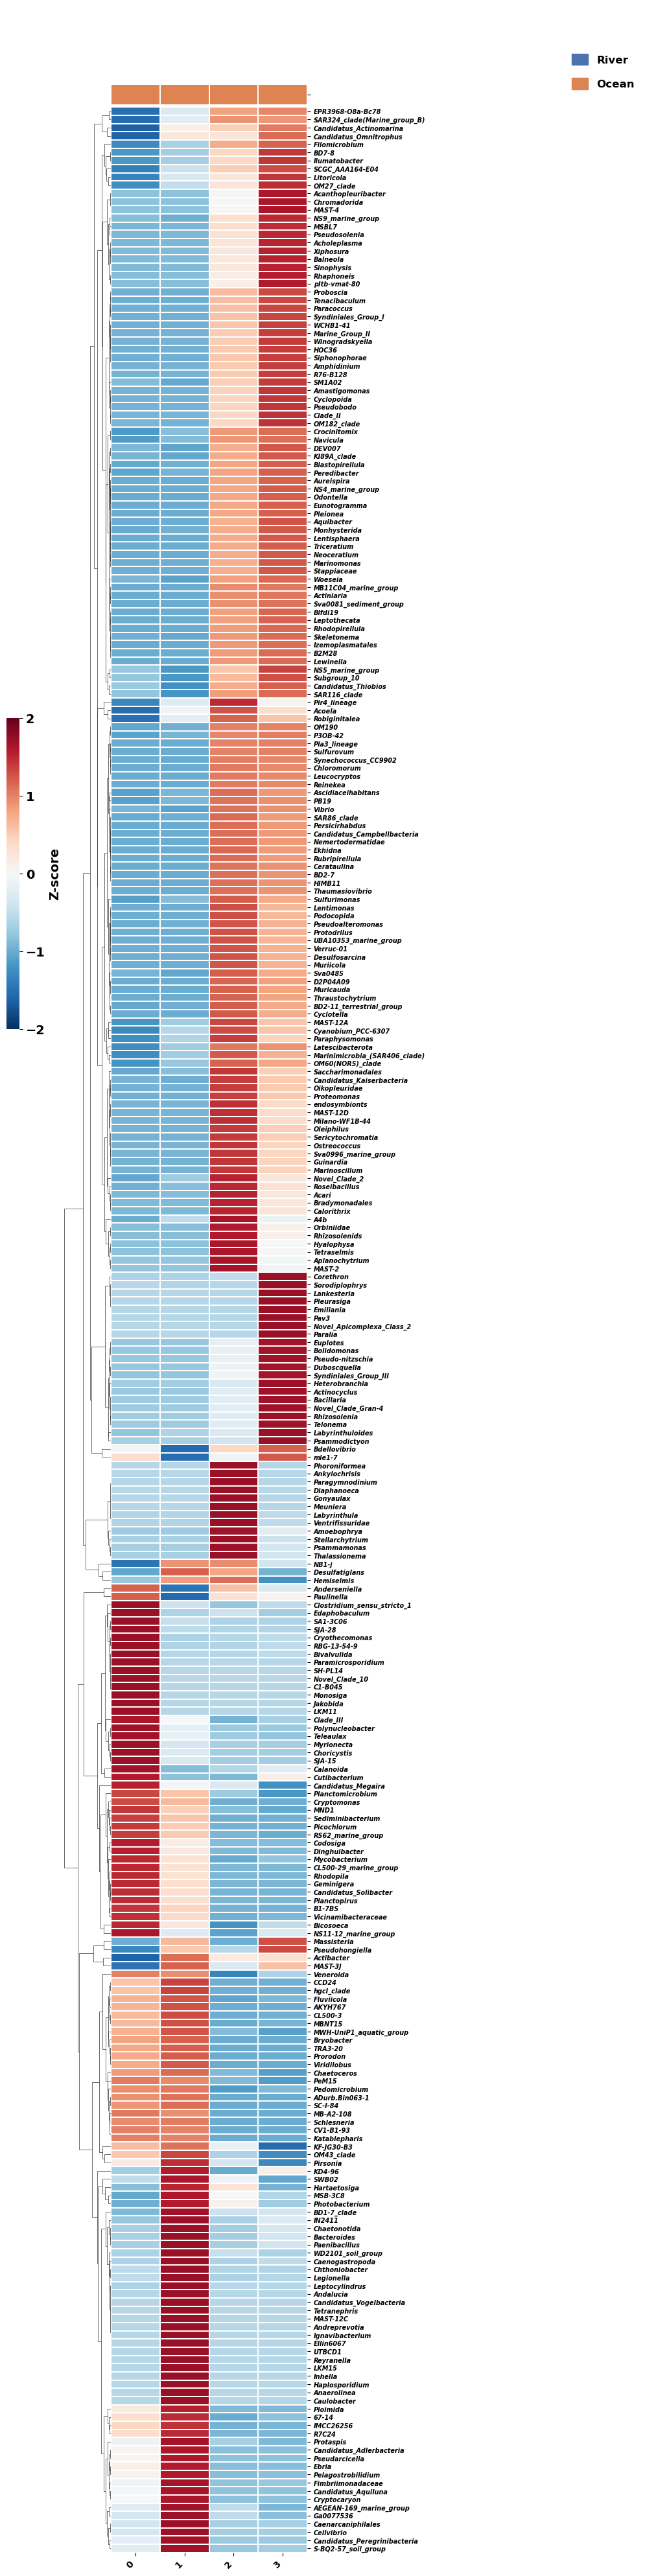

In [221]:
# Plot heatmap of row-wise z-scored genus abundance with clustering
# Add river vs ocean sample annotation and use centered diverging colormap
# Adjust layout, labels, and save as publication-quality PDF

import seaborn as sns
import matplotlib.patches as mpatches

river_samples_merged = ["PAMA-1", "PAMA-2"]
col_colors = pd.Series(
    ["#4C72B0" if s in river_samples_merged else "#DD8452"
     for s in genus_z_merged.columns],
    index=genus_z_merged.columns
)
g = sns.clustermap(
    genus_z_merged,
    col_colors=col_colors,
    cmap="RdBu_r",
    center=0,
    figsize=(8, 40),
    col_cluster=False,
    row_cluster=True,
    yticklabels=True,
    xticklabels=True,
    linewidths=0.3,
    cbar_pos=(-0.08, 0.6, 0.025, 0.12),
    vmin=-2, vmax=2,
    cbar_kws={"label": "Z-score", "ticks": [-2, -1, 0, 1, 2]},
    dendrogram_ratio=(0.20, 0.03),
    colors_ratio=0.008,
)
g.ax_heatmap.set_xticklabels(
    g.ax_heatmap.get_xticklabels(), rotation=45, ha="right", fontsize=10
)
g.ax_heatmap.set_yticklabels(
    g.ax_heatmap.get_yticklabels(), rotation=0, fontsize=7, style="italic"
)
g.ax_heatmap.set_xlabel("")
g.ax_heatmap.set_ylabel("")

river_patch = mpatches.Patch(color="#4C72B0", label="River")
ocean_patch = mpatches.Patch(color="#DD8452", label="Ocean")

g.fig.legend(
    handles=[river_patch, ocean_patch],
    loc="upper right",
    bbox_to_anchor=(1.15, 0.98),
    frameon=False,
    fontsize=12,
    handlelength=1.5,
    handleheight=1.2,
    labelspacing=1.2,
)

plt.savefig(out_dir+ "PAMA_genus_heatmap_merged.pdf", bbox_inches="tight", dpi=300)
plt.show()

In [222]:
# Ensure using the cleaned matrix (after dropna)
heatmap_df = genus_z_merged.copy()

# Reset index so "Genus" becomes a column (important for CSV clarity)
heatmap_df = heatmap_df.reset_index()

# Save to CSV
heatmap_df.to_csv(out_dir+"pama_heatmap_input_table.csv", index=False)

PCoA input shape: (8, 964)
Sample sums (should be close to 1.0):
SampleID
OL-PAMA-1a    1.0
OL-PAMA-1b    1.0
OL-PAMA-2a    1.0
OL-PAMA-2b    1.0
OL-PAMA-3a    1.0
OL-PAMA-3b    1.0
OL-PAMA-4a    1.0
OL-PAMA-4b    1.0
dtype: float64
     SampleID  Group Replicate ShortLabel
0  OL-PAMA-1a  River         a    PAMA-1a
1  OL-PAMA-1b  River         b    PAMA-1b
2  OL-PAMA-2a  River         a    PAMA-2a
3  OL-PAMA-2b  River         b    PAMA-2b
4  OL-PAMA-3a  Ocean         a    PAMA-3a
5  OL-PAMA-3b  Ocean         b    PAMA-3b
6  OL-PAMA-4a  Ocean         a    PAMA-4a
7  OL-PAMA-4b  Ocean         b    PAMA-4b

Bray-Curtis distance matrix:
SampleID    OL-PAMA-1a  OL-PAMA-1b  OL-PAMA-2a  OL-PAMA-2b  OL-PAMA-3a  \
SampleID                                                                 
OL-PAMA-1a      0.0000      0.2367      0.4486      0.5080      0.6338   
OL-PAMA-1b      0.2367      0.0000      0.4162      0.4622      0.6407   
OL-PAMA-2a      0.4486      0.4162      0.0000      0.2704     

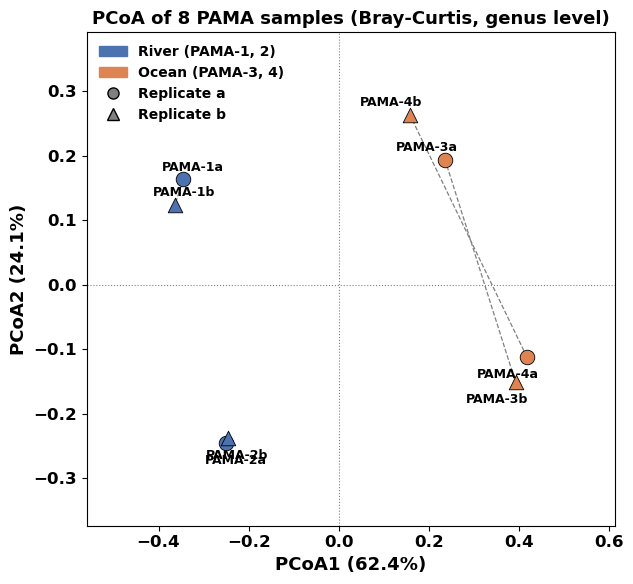

In [223]:
# Classical PCoA on all 8 PAMA samples
# Bray-Curtis distance + exact eigen decomposition
# Replicate a/b distinguished by marker shape, connected by dashed lines

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from scipy.spatial.distance import pdist, squareform
from matplotlib.lines import Line2D

# =========================
# 1. Prepare sample-by-genus matrix
# =========================
pcoa_input = genus_matrix.T.copy()
print("PCoA input shape:", pcoa_input.shape)
print("Sample sums (should be close to 1.0):")
print(pcoa_input.sum(axis=1).round(4))

# =========================
# 2. Metadata
# =========================
metadata = pd.DataFrame({"SampleID": pcoa_input.index.tolist()})

metadata["Group"] = metadata["SampleID"].map({
    "OL-PAMA-1a": "River", "OL-PAMA-1b": "River",
    "OL-PAMA-2a": "River", "OL-PAMA-2b": "River",
    "OL-PAMA-3a": "Ocean", "OL-PAMA-3b": "Ocean",
    "OL-PAMA-4a": "Ocean", "OL-PAMA-4b": "Ocean",
})
metadata["Replicate"] = metadata["SampleID"].apply(
    lambda x: "a" if x.endswith("a") else "b"
)
metadata["ShortLabel"] = metadata["SampleID"].str.replace("OL-PAMA-", "PAMA-", regex=False)
print(metadata)

# =========================
# 3. Bray-Curtis distance matrix
# =========================
D = squareform(pdist(pcoa_input.values, metric="braycurtis"))
dist_df = pd.DataFrame(D, index=pcoa_input.index, columns=pcoa_input.index)
print("\nBray-Curtis distance matrix:")
print(dist_df.round(4))

# =========================
# 4. Classical PCoA (exact eigen decomposition)
# =========================
n = D.shape[0]

# Double-centering
H = np.eye(n) - np.ones((n, n)) / n
B = -0.5 * H @ (D ** 2) @ H

# Eigen decomposition
eigvals, eigvecs = np.linalg.eigh(B)

# Sort descending
idx = np.argsort(eigvals)[::-1]
eigvals = eigvals[idx]
eigvecs = eigvecs[:, idx]

# Keep only positive eigenvalues
positive = eigvals > 0
eigvals_pos = eigvals[positive]
eigvecs_pos = eigvecs[:, positive]

# PCoA coordinates (first two axes)
coords = eigvecs_pos[:, :2] * np.sqrt(eigvals_pos[:2])

# Explained variance
var_explained = eigvals_pos / eigvals_pos.sum()
pc1_pct = var_explained[0] * 100
pc2_pct = var_explained[1] * 100
print(f"\nPCoA1: {pc1_pct:.1f}%")
print(f"PCoA2: {pc2_pct:.1f}%")

# =========================
# 5. Build coordinate DataFrame
# =========================
pcoa_df = pd.DataFrame(
    coords, columns=["PCoA1", "PCoA2"],
    index=pcoa_input.index
).reset_index().rename(columns={"index": "SampleID"})
pcoa_df = pcoa_df.merge(metadata, on="SampleID", how="left")
print(pcoa_df)

# =========================
# 6. Plot
# =========================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Liberation Sans", "Helvetica"],
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
    "font.weight": "bold",
    "axes.labelweight": "bold",
    "axes.titleweight": "bold",
    "font.size": 12,
})

group_colors  = {"River": "#4C72B0", "Ocean": "#DD8452"}
rep_markers   = {"a": "o", "b": "^"}   # circle = replicate a, triangle = replicate b

# --- compute axis limits with padding BEFORE plotting ---
x_pad = (pcoa_df["PCoA1"].max() - pcoa_df["PCoA1"].min()) * 0.25
y_pad = (pcoa_df["PCoA2"].max() - pcoa_df["PCoA2"].min()) * 0.25
xlim = (pcoa_df["PCoA1"].min() - x_pad, pcoa_df["PCoA1"].max() + x_pad)
ylim = (pcoa_df["PCoA2"].min() - y_pad, pcoa_df["PCoA2"].max() + y_pad)

fig, ax = plt.subplots(figsize=(6.5, 6.0))

# -- scatter points --
for _, row in pcoa_df.iterrows():
    ax.scatter(
        row["PCoA1"], row["PCoA2"],
        s=110,
        color=group_colors[row["Group"]],
        marker=rep_markers[row["Replicate"]],
        edgecolor="black",
        linewidth=0.6,
        zorder=3,
    )

# -- dashed lines connecting replicate a/b pairs --
replicate_pairs = [
    ("OL-PAMA-1a", "OL-PAMA-1b"),
    ("OL-PAMA-2a", "OL-PAMA-2b"),
    ("OL-PAMA-3a", "OL-PAMA-3b"),
    ("OL-PAMA-4a", "OL-PAMA-4b"),
]
for sa, sb in replicate_pairs:
    xa, ya = pcoa_df.loc[pcoa_df["SampleID"] == sa, ["PCoA1", "PCoA2"]].values[0]
    xb, yb = pcoa_df.loc[pcoa_df["SampleID"] == sb, ["PCoA1", "PCoA2"]].values[0]
    ax.plot([xa, xb], [ya, yb], color="gray", lw=0.9, ls="--", zorder=1)

# -- sample labels: smart offset to avoid going outside plot --
x_range = xlim[1] - xlim[0]
y_range = ylim[1] - ylim[0]
x_mid   = (xlim[0] + xlim[1]) / 2
y_mid   = (ylim[0] + ylim[1]) / 2

for _, row in pcoa_df.iterrows():
    # shift label away from the nearest axis edge
    dx = -0.035 * x_range if row["PCoA1"] > x_mid else 0.018 * x_range
    dy =  0.025 * y_range if row["PCoA2"] > y_mid else -0.035 * y_range
    ax.text(
        row["PCoA1"] + dx,
        row["PCoA2"] + dy,
        row["ShortLabel"],
        fontsize=9,
        ha="center", va="center",
    )

# -- reference lines --
ax.axhline(0, color="gray", linestyle=":", linewidth=0.8)
ax.axvline(0, color="gray", linestyle=":", linewidth=0.8)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.set_xlabel(f"PCoA1 ({pc1_pct:.1f}%)", fontsize=13)
ax.set_ylabel(f"PCoA2 ({pc2_pct:.1f}%)", fontsize=13)
ax.set_title("PCoA of 8 PAMA samples (Bray-Curtis, genus level)", fontsize=13)

# -- legend --
legend_handles = [
    mpatches.Patch(color=group_colors["River"], label="River (PAMA-1, 2)"),
    mpatches.Patch(color=group_colors["Ocean"], label="Ocean (PAMA-3, 4)"),
    Line2D([0], [0], marker="o", color="gray", label="Replicate a",
           markerfacecolor="gray", markeredgecolor="black", markersize=8, linestyle="None"),
    Line2D([0], [0], marker="^", color="gray", label="Replicate b",
           markerfacecolor="gray", markeredgecolor="black", markersize=8, linestyle="None"),
]
ax.legend(handles=legend_handles, frameon=False, fontsize=10, loc="best")

plt.tight_layout()
plt.savefig(out_dir + "PAMA_PCoA_braycurtis_final.pdf", bbox_inches="tight")
plt.show()

# =========================
# 7. Export tables
# =========================
dist_df.to_csv(out_dir + "pama_pcoa_braycurtis_distance_matrix_8samples.csv")
pcoa_df.to_csv(out_dir + "pama_pcoa_coordinates_8samples.csv", index=False)